# Desafio Maker - Data Science Hackaton

## Objetivo
O presente arquivo apresenta a etapa de exploração e conhecimento dos dados utilizados no desafio técnico.

O principal objetivo desta fase é compreender a estrutura da base, identificar possíveis problemas de qualidade dos dados recebidos e definir uma estratégia de tratamento antes da realização das análises de negócio.

As análises desenvolvidas neste notebook servirão como base para o desenvolvimento da solução final em Python.

# 1. Importação das bibliotecas

Nesta seção são importadas as bibliotecas utilizadas ao longo da análise. 

Cada uma delas possui uma finalidade específica:
- **Pandas**: manipulação e análise dos dados;
- **NumPy**: operações matemáticas e tratamento numérico;
- **Matplotlib**: criação de gráficos;
- **Seaborn**: visualizações estatísticas;
- **Pathlib**: manipulação de caminhos de arquivos.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configuração do ambiente

Antes de iniciar a análise, algumas configurações foram definidas com a finalidade de melhorar a visualização das informações durante o decorrer do projeto.

Essas configurações não alteram a fonte original dos dados, apenas tornam a apresentação mais clara.

In [3]:
# Exibe todas as colunas dos DataFrames
pd.set_option("display.max_columns", None)

# Ajusta a quantidade máxima de linhas que aparecem
pd.set_option("display.max_rows", 100)

# Definição do tamanho padrão das figuras
plt.rcParams["figure.figsize"] = (10, 6)

# Aplica um tema padrão aos gráficos
sns.set_theme(style="whitegrid")

# 3. Carregamento dos dados

O desafio disponibilizou duas bases de dados em um único arquivo Excel.

As planilhas serão carregadas separadamente para facilitar a exploração individual de cada conjunto de dados e permitir cruzamentos posteriores durante a análise.

In [5]:
# Variável constante com o caminho do arquivo disponibilizado no desafio
CAMINHO_DADOS = Path('../data/db_atlas.xlsx')

# Carrega o histórico de cotações
historico_cotacoes = pd.read_excel(
    CAMINHO_DADOS,
    sheet_name="HISTORICO_COTACOES"
)

# Carrega as informações da frota
frota_ativos = pd.read_excel(
    CAMINHO_DADOS,
    sheet_name="FROTA_ATIVOS"
)

# 4. Compreendendo a base

Antes de realizar qualquer tipo de alteração, é importante compreender a estrutura das bases originalmente disponibilizadas.

Nesta parte, serão respondidos questionamentos como:
- Qual a quantidade total de registros existentes?
- Quais dados estão disponíveis?
- Quais os tipos de cada variável
- Existems possíveis inconsitências já perceptíveis?

In [7]:
display(historico_cotacoes.head())

display(frota_ativos.head())

,Client_Name,Quote_Date,Quote_ID,Close_Date,Days_To_Close,Serial_ID,Amount_BRL,Stage
0,Rosberg Energy 429,2023-09-05 00:27:21,QT-100000,2023-10-12 00:27:21,NaN,SN-10144,42865.48,Perdido
1,Mansell Agro 996,2023-08-22 07:54:37,QT-100001,2023-10-03 07:54:37,42.0,SN-10253,42139.31,Perdido
2,Verstappen Logistics 715,2023-07-28 09:59:33,QT-100002,2023-07-29 09:59:33,1.0,SN-10130,44611.83,Ganho
3,Clark Dynamics 461,2023-09-12 08:33:55,QT-100003,2023-10-23 08:33:55,41.0,SN-10249,39920.19,Perdido
4,Stewart Agro 422,06/02/2024,QT-100004,2024-03-15 07:46:46,38.0,SN-10463,26830.45,Ganho


,Serial_ID,F1_Model,Solution_Type,Acquisition_Cost_BRL,Accumulated_Depreciation_BRL,Total_Maintenance_Cost_BRL
0,SN-10000,MP4/4,Solução 1,237454.01,223825.85,246761.35
1,SN-10001,MP4/4,Solução 1,259865.85,213974.27,180242.10
2,SN-10002,MP4/4,Solução 1,205808.36,191386.63,197713.71
3,SN-10003,MP4/4,Solução 1,270807.26,217481.97,320079.53
4,SN-10004,MP4/4,Solução 1,283244.26,235616.99,200847.09


In [8]:
print(
    f"Histórico de cotações: {historico_cotacoes.shape[0]} registros e {historico_cotacoes.shape[1]} colunas."
)

print(
    f"Frota de ativos: {frota_ativos.shape[0]} registros e {frota_ativos.shape[1]} colunas."
)

Histórico de cotações: 6000 registros e 8 colunas.
Frota de ativos: 580 registros e 6 colunas.


## Interpretação

A consulta da dimensão permite compreender o volume de dados disponível para análise. Essa informação também auxilia na escolha de estratégias de tratamento e visualização.

In [9]:
historico_cotacoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Client_Name    6000 non-null   str           
 1   Quote_Date     6000 non-null   object        
 2   Quote_ID       6000 non-null   str           
 3   Close_Date     6000 non-null   datetime64[us]
 4   Days_To_Close  5682 non-null   float64       
 5   Serial_ID      6000 non-null   str           
 6   Amount_BRL     6000 non-null   float64       
 7   Stage          6000 non-null   str           
dtypes: datetime64[us](1), float64(2), object(1), str(4)
memory usage: 375.1+ KB


In [10]:
frota_ativos.info()

<class 'pandas.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Serial_ID                     580 non-null    str    
 1   F1_Model                      580 non-null    str    
 2   Solution_Type                 580 non-null    str    
 3   Acquisition_Cost_BRL          580 non-null    float64
 4   Accumulated_Depreciation_BRL  580 non-null    float64
 5   Total_Maintenance_Cost_BRL    580 non-null    float64
dtypes: float64(3), str(3)
memory usage: 27.3 KB


### Interpretação

Observa-se que as bases possuem colunas numéricas, categóricas e temporais.

Também é possível identificar valor ausentes ou que diferem do padrão estabelecido pelo restante dos dados registrados, aspecto que será investigado na próxima etapa.

# 5. Avaliação da qualidade dos dados

Esta etapa busca encontrar possíveis problemas que possam comprometer a confiabilidade das análises futuras.

Serão avalliados os seguintes aspectos:
- Valores ausentes;
- Registros duplicados;
- Tipos de dados;
- Estatísticas descritivas;
- Valores únicos em variáveis categóricas;
- Consistência entre os registros.

## 5.1 Verificação de valores ausentes
Valores ausentes podem destacar falhas no processo de coleta, integração ou armazenamento dos dados.

Nesta seção, será identificado o número absoluto e o percentual de valores nulos em cada coluna de ambas as bases.


In [11]:
def analisar_valores_ausentes(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Retorna a quantidade e o percentual de valores ausentes por coluna.
    """

    valores_ausentes = dataframe.isna().sum()

    percentual_ausentes = (
        dataframe.isna().mean() * 100
    ).round(2)

    resultado = pd.DataFrame({
        "Valores ausentes": valores_ausentes,
        "Percentual (%)": percentual_ausentes
    })

    return resultado.sort_values(
        by="Percentual (%)",
        ascending=False
    )

In [12]:
print("Histórico de Cotações")
display(analisar_valores_ausentes(historico_cotacoes))

Histórico de Cotações


,Valores ausentes,Percentual (%)
Days_To_Close,318,5.3
Client_Name,0,0.0
Quote_ID,0,0.0
Quote_Date,0,0.0
Close_Date,0,0.0
Serial_ID,0,0.0
Amount_BRL,0,0.0
Stage,0,0.0


In [13]:
print("Frota de Ativos")
display(analisar_valores_ausentes(frota_ativos))

Frota de Ativos


,Valores ausentes,Percentual (%)
Serial_ID,0,0.0
F1_Model,0,0.0
Solution_Type,0,0.0
Acquisition_Cost_BRL,0,0.0
Accumulated_Depreciation_BRL,0,0.0
Total_Maintenance_Cost_BRL,0,0.0


## Interpretação

Foi possível identificar que a coluna `Days_To_Close` do histórico de transações apresenta valores ausentes.

Futuramente será avaliado se há possibilidade de recuperar esses registros, tratados ou removidos sem comprometer as análises de negócio.

## Verificação de registros duplicados

Registros duplicados podem afetar os insights egerar distorções em indicadores como quantidade de cotações, taxa de conversão e faturamento.

Por essas razões, será avaliada a existência de linhas completamente duplicadas nas duas bases.

In [17]:
def contar_duplicados(dataframe: pd.DataFrame) -> int:
    """
    Retorna a quantidade de registros duplicados.
    """
    return dataframe.duplicated().sum()

In [18]:
print(
    f"Duplicados no histórico: {contar_duplicados(historico_cotacoes)}"
)

print(
    f"Duplicados na frota: {contar_duplicados(frota_ativos)}"
)

Duplicados no histórico: 0
Duplicados na frota: 0


## 5.3 Estatísticas descritivas

As estatísticas descritivas permitem compreender a distribuição das variáveis numéricas.

Serão analisados indicadores como média, desvio padrão, valores mínimos, máximos e quartis.

In [19]:
display(
    historico_cotacoes.describe().T
)

,count,mean,min,25%,50%,75%,max,std
Close_Date,6000,2025-02-10 21:55:27.385166,2023-07-25 09:33:19,2024-05-12 19:20:57.250000,2025-02-13 06:57:05,2025-11-11 18:36:38.500000,2026-10-30 01:17:20,NaN
Days_To_Close,5682.0,24.831749,0.0,6.0,20.0,37.0,174.0,22.269995
Amount_BRL,6000.0,50419.1581,-144294.072538,19447.56,30783.225,42134.1875,9999999.99,407679.091778


In [20]:
display(
    frota_ativos.describe().T
)

,count,mean,std,min,25%,50%,75%,max
Acquisition_Cost_BRL,580.0,173038.975552,54566.271942,100756.29,133873.8725,162772.925,192085.395,349005.39
Accumulated_Depreciation_BRL,580.0,85666.261552,49299.568321,15016.24,56048.8925,72847.080,95120.050,278623.92
Total_Maintenance_Cost_BRL,580.0,53369.216914,57659.842276,3126.50,23298.6150,36942.415,54170.320,320079.53


### Interpretação

A análise estatística revelou valores extremos na coluna `Amount_BRL`, incluindo propostas com valores negativos e uma proposta com valor significativamente superior ao restante da distribuição.

Antes de qualquer tratamento, esses registros serão investigados individualmente para verificar se representam erros de preenchimento ou situações válidas do negócio.

## 5.4 Análise das variáveis categóricas

Antes de realizar agrupamentos, é importante compreender os valores existentes nas variáveis categóricas.

Essa análise permite identificar categorias inconsistentes e possíveis problemas de padronização.

In [22]:
def analisar_variavel_categorica(
    dataframe: pd.DataFrame,
    coluna: str
) -> None:
    """
    Exibe a frequência de cada categoria.
    """

    display(
        dataframe[coluna]
        .value_counts(dropna=False)
    )

In [24]:
analisar_variavel_categorica(
    historico_cotacoes,
    "Stage"
)

Stage
Perdido     2882
Ganho       2216
Perdido      137
ganho        135
lost         133
 WON         128
GAnho        125
W0n          123
 Not Won     121
Name: count, dtype: int64

# 6. Investigação das Inconsistências Encontradas

A etapa de avaliação da qualidade dos dados identificou algumas inconsistências que podem impactar diretamente os resultados das análises.

Antes de aplicar qualquer transformação, cada uma delas será investigada individualmente para compreender sua origem e definir a estratégia de tratamento mais adequada.

As principais inconsistências encontradas foram:

- Valores ausentes na coluna `Days_To_Close`;
- Falta de padronização na coluna `Stage`.

## 6.1 Investigação dos valores ausentes em `Days_To_Close`

A coluna `Days_To_Close` apresentou registros sem informação durante a avaliação da qualidade dos dados.

Antes de decidir pela remoção ou preenchimento desses valores, é importante verificar se sua ausência está relacionada a alguma regra de negócio, como cotações ainda em andamento ou não concluídas.

In [58]:
historico_cotacoes[
    ["Quote_Date", "Close_Date"]
].dtypes

Quote_Date    datetime64[us]
Close_Date    datetime64[us]
dtype: object

In [59]:
# Converte a coluna de texto para data utilizando o padrão dia/mês/ano

historico_cotacoes["Quote_Date"] = pd.to_datetime(
    historico_cotacoes["Quote_Date"],
    dayfirst=True
)

In [60]:
historico_cotacoes[
    ["Quote_Date", "Close_Date"]
].dtypes

Quote_Date    datetime64[us]
Close_Date    datetime64[us]
dtype: object

In [61]:
historico_cotacoes["Days_To_Close"] = (
    historico_cotacoes["Close_Date"] - historico_cotacoes["Quote_Date"]
).dt.days

In [62]:
historico_cotacoes.head()

,Client_Name,Quote_Date,Quote_ID,Close_Date,Days_To_Close,Serial_ID,Amount_BRL,Stage
0,Rosberg Energy 429,2023-09-05 00:27:21,QT-100000,2023-10-12 00:27:21,37,SN-10144,42865.48,Perdido
1,Mansell Agro 996,2023-08-22 07:54:37,QT-100001,2023-10-03 07:54:37,42,SN-10253,42139.31,Perdido
2,Verstappen Logistics 715,2023-07-28 09:59:33,QT-100002,2023-07-29 09:59:33,1,SN-10130,44611.83,Ganho
3,Clark Dynamics 461,2023-09-12 08:33:55,QT-100003,2023-10-23 08:33:55,41,SN-10249,39920.19,Perdido
4,Stewart Agro 422,2024-02-06 00:00:00,QT-100004,2024-03-15 07:46:46,38,SN-10463,26830.45,Ganho


## Interpretação

A coluna `Quote_Date` estava armazenada como texto (`object`), impossibilitando operações envolvendo datas.

Durante a inspeção foi identificado que os registros seguem o padrão `dd/mm/yyyy`. Dessa forma, a conversão foi realizada utilizando um formato explícito (`%d/%m/%Y`), eliminando ambiguidades na interpretação das datas e garantindo a consistência dos cálculos temporais.

A coluna `Dias_Calculados` serve temporariamente para mostrar a versão Corrigida de `Days_To_Close`

## 6.2 Investigação dos valores extremos em `Amount_BRL`

Durante a análise estatística da base foram identificados valores significativamente diferentes da distribuição geral da variável `Amount_BRL`.

Antes de qualquer tratamento, esses registros serão analisados individualmente para verificar se representam inconsistências nos dados ou situações válidas do processo de negócio.

Essa abordagem evita a remoção de informações potencialmente relevantes e garante que qualquer transformação seja baseada em evidências.

In [63]:
# Exibe todas as cotações com valor negativo
historico_cotacoes.loc[
    historico_cotacoes["Amount_BRL"] < 0
]

,Client_Name,Quote_Date,Quote_ID,Close_Date,Days_To_Close,Serial_ID,Amount_BRL,Stage
10,Hamilton Energy 658,2024-03-02 20:07:32,QT-100010,2024-03-17 20:07:32,15,SN-10556,-26565.260000,Perdido
14,Perez Aero 521,2023-10-24 04:21:06,QT-100014,2023-12-10 04:21:06,47,SN-10443,-18542.690000,Ganho
27,Alonso Corp 487,2023-08-24 13:42:52,QT-100027,2023-09-03 13:42:52,10,SN-10479,-38088.530000,Ganho
93,Piquet Logistics 584,2024-01-26 00:00:00,QT-100093,2024-01-28 00:27:22,2,SN-10326,-39358.930000,Ganho
111,Hakkinen Dynamics 439,2023-10-10 00:00:00,QT-100111,2023-11-18 08:10:13,39,SN-10426,-27007.010000,Perdido
...,...,...,...,...,...,...,...,...
5911,Fangio Heavy Machining 136,2025-10-26 03:10:51,QT-105911,2025-11-03 03:10:51,8,SN-10032,-99643.711512,Ganho
5949,Hamilton Agro 685,2025-09-21 05:09:27,QT-105949,2025-10-29 05:09:27,38,SN-10187,-29588.830000,Perdido
5950,Rosberg Agro 556,2026-03-18 13:08:27,QT-105950,2026-07-04 13:08:27,108,SN-10104,-10291.230000,Ganho
5965,Prost Logistics 121,2025-07-26 04:34:01,QT-105965,2025-07-28 04:34:01,2,SN-10074,-20772.180000,Ganho


In [ ]:
# Exibe cotações com valores excepcionalmente altos
historico_cotacoes.loc

,Client_Name,Quote_Date,Quote_ID,Close_Date,Days_To_Close,Serial_ID,Amount_BRL,Stage
0,Rosberg Energy 429,2023-09-05 00:27:21,QT-100000,2023-10-12 00:27:21,37,SN-10144,42865.480000,Perdido
1,Mansell Agro 996,2023-08-22 07:54:37,QT-100001,2023-10-03 07:54:37,42,SN-10253,42139.310000,Perdido
2,Verstappen Logistics 715,2023-07-28 09:59:33,QT-100002,2023-07-29 09:59:33,1,SN-10130,44611.830000,Ganho
3,Clark Dynamics 461,2023-09-12 08:33:55,QT-100003,2023-10-23 08:33:55,41,SN-10249,39920.190000,Perdido
4,Stewart Agro 422,2024-02-06 00:00:00,QT-100004,2024-03-15 07:46:46,38,SN-10463,26830.450000,Ganho
...,...,...,...,...,...,...,...,...
5995,Clark Heavy Machining 667,2026-02-21 04:34:55,QT-105995,2026-03-15 04:34:55,22,SN-10039,100401.593675,Ganho
5996,Alonso Corp 684,2025-12-21 14:06:45,QT-105996,2026-01-16 14:06:45,26,SN-10530,40089.640000,Ganho
5997,Schumacher Heavy Machining 832,2026-04-24 12:21:07,QT-105997,2026-05-29 12:21:07,35,SN-10098,-37115.520000,Perdido
5998,Rosberg Industries 358,2025-11-27 17:06:44,QT-105998,2025-12-25 17:06:44,28,SN-10018,31750.260000,Perdido


## Interpretação

A investigação identificou registros com valores negativos e registros com o valor fixo de R$ 9.999.999,99 na coluna `Amount_BRL`.

Esses valores se diferenciam significativamente da distribuição geral dos dados e merecem atenção. No entanto, como não há documentação da base nem regras de negócio que permitam classificá-los como erros, não será realizado nenhum tratamento nesta etapa.

Os registros serão preservados para manter a integridade da base e eventuais análises que utilizem a coluna `Amount_BRL` deverão considerar a presença desses valores extremos em sua interpretação.

## 6.3 Padronização da coluna `Stage`

A coluna `Stage` representa o resultado final de cada cotação e será utilizada em diversos indicadores, como taxa de conversão e análises de desempenho.

Durante a inspeção dos dados foram identificadas diferentes representações para um mesmo status, incluindo diferenças de idioma, capitalização, espaços em branco e erros de digitação.

Antes da padronização, foram listados todos os valores distintos presentes na coluna.

In [27]:
# Listando todos os diferentes registros de categoria na coluna stage

categorias_stage = (
    historico_cotacoes["Stage"]
    .unique()
)

categorias_stage

<StringArray>
[ 'Perdido',    'Ganho', 'Perdido ',     ' WON',    'GAnho',     'lost',
 ' Not Won',    'ganho',      'W0n']
Length: 9, dtype: str

### Interpretação

Foram identificadas nove maneiras diferentes de representar os registros do status das cotações.

Embora existam apenas dois estados de negócio ("Ganho" e "Perdido"), a coluna apresenta inconsistências como:

- utilização simultânea de português e inglês;
- diferenças entre letras maiúsculas e minúsculas;
- espaços em branco no início e no final dos textos;
- erro de digitação (`W0n`, utilizando o número zero em vez da letra "O").

Essas inconsistências fariam com que registros pertencentes à mesma categoria fossem analisados separadamente, comprometendo indicadores como a taxa de conversão.

Dessa forma, será realizada a padronização da coluna antes das análises exploratórias.

In [28]:
# A padronização será realizada em três etapas:
# 1. Remover espaços em branco no início e no final dos textos;
# 2. Uniformizar a capitalização para facilitar a comparação entre valores;
# 3. Mapear todas as representações equivalentes para apenas duas categorias: "Ganho" e "Perdido".

# Remove espaços em branco excedentes
historico_cotacoes["Stage"] = historico_cotacoes["Stage"].str.strip()

# Padroniza a escrita para letras minúsculas
historico_cotacoes["Stage"] = historico_cotacoes["Stage"].str.lower()

# Mapeia todas as variações para uma representação única
MAPEAMENTO_STAGE = {
    "ganho": "Ganho",
    "won": "Ganho",
    "w0n": "Ganho",
    "perdido": "Perdido",
    "lost": "Perdido",
    "not won": "Perdido",
}

historico_cotacoes["Stage"] = historico_cotacoes["Stage"].replace(MAPEAMENTO_STAGE)

## 7.3 Identificação e tratamento de outliers

A coluna `Amount_BRL` apresentou valores significativamente diferentes da distribuição geral.

Para identificar esses registros de forma objetiva, foi utilizado o método do Intervalo Interquartil (IQR), amplamente empregado na detecção de valores extremos.

Após a identificação, os registros foram analisados individualmente antes da definição da estratégia de tratamento.

In [69]:
# Calcula os quartis da distribuição
q1 = historico_cotacoes["Amount_BRL"].quantile(0.25)
q3 = historico_cotacoes["Amount_BRL"].quantile(0.75)

# Calcula o Intervalo Interquartil (IQR)
iqr = q3 - q1

# Define os limites para identificação de outliers
limite_inferior = q1 - (1.5 * iqr)
limite_superior = q3 + (1.5 * iqr)

# Aplica Winsorização, limitando os valores extremos aos limites calculados
historico_cotacoes["Amount_BRL"] = historico_cotacoes["Amount_BRL"].clip(
    lower=limite_inferior,
    upper=limite_superior
)

In [71]:
# Estatísticas após o tratamento dos outliers
historico_cotacoes["Amount_BRL"].describe()

count     6000.000000
mean     31755.149357
std      19206.999644
min     -14582.381250
25%      19447.560000
50%      30783.225000
75%      42134.187500
max      76164.128750
Name: Amount_BRL, dtype: float64

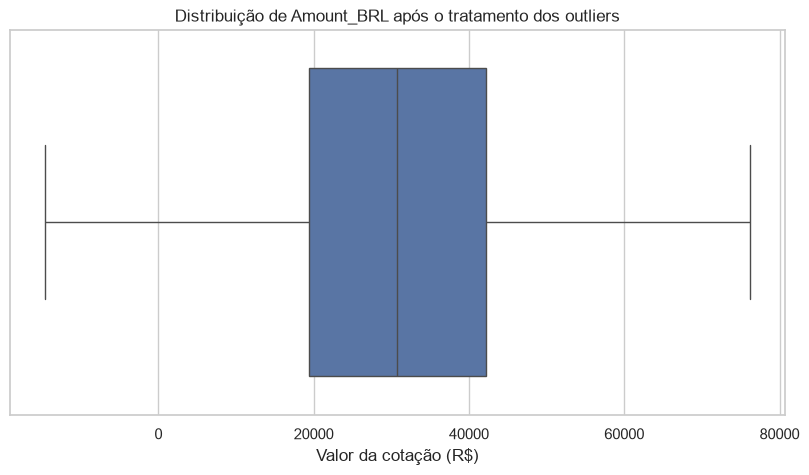

In [72]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=historico_cotacoes["Amount_BRL"]
)

plt.title("Distribuição de Amount_BRL após o tratamento dos outliers")
plt.xlabel("Valor da cotação (R$)")

plt.show()